# PokeGen — Generating Pokémon Names with a Transformer

This notebook walks through building a **character-level text generator** from scratch using a **decoder-only Transformer** in PyTorch.

**Goal:** Train a model on the ~1,350 official Pokémon names and have it generate new, plausible-sounding names.

### What you'll see in this notebook

1. **Data collection** — Fetching all Pokémon names from the PokéAPI
2. **Tokenization** — Character-level encoding with start/end/pad tokens
3. **Model architecture** — Building a Transformer decoder block by block
4. **Training** — Training loop with validation, early stopping, and learning rate scheduling
5. **Generation** — Autoregressive sampling with temperature control

In [11]:
import math

import httpx
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Collection

We fetch all Pokémon names from the [PokéAPI](https://pokeapi.co/). This gives us ~1,350 names like `bulbasaur`, `charizard`, `pikachu`, etc.

In [12]:
response = httpx.get("https://pokeapi.co/api/v2/pokemon/?limit=2000")
response.raise_for_status()
names = [p["name"] for p in response.json()["results"]]
print(f"Loaded {len(names)} Pokémon names")
print("Examples:", names[:10])

Loaded 1350 Pokémon names
Examples: ['bulbasaur', 'ivysaur', 'venusaur', 'charmander', 'charmeleon', 'charizard', 'squirtle', 'wartortle', 'blastoise', 'caterpie']


## 2. Tokenization

We use **character-level tokenization** with three special tokens:
- `<S>` — start of name
- `<E>` — end of name
- `<P>` — padding (to make all sequences the same length)

Each name becomes a sequence of integers: `bulbasaur` → `[<S>, b, u, l, b, a, s, a, u, r, <E>, <P>, ...]`

In [13]:
# Build the vocabulary from all unique characters
START, END, PAD = "<S>", "<E>", "<P>"
chars = sorted(set().union(*names))
alphabet = [START, END, PAD] + chars

idx_to_char = dict(enumerate(alphabet))
char_to_idx = {v: k for k, v in idx_to_char.items()}

print(f"Vocabulary size: {len(alphabet)}")
print(f"Characters: {alphabet}")

Vocabulary size: 34
Characters: ['<S>', '<E>', '<P>', '-', '0', '1', '2', '5', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [14]:
# Tokenize, encode, and pad all names into a batch
tokenized = [[START] + list(name) + [END] for name in names]
max_length = max(map(len, tokenized))

encoded = [torch.tensor([char_to_idx[t] for t in tokens]) for tokens in tokenized]
batch = pad_sequence(encoded, batch_first=True, padding_value=char_to_idx[PAD])

# Split into inputs (all tokens except last) and targets (all tokens except first)
inputs = batch[:, :-1]
targets = batch[:, 1:]

print(f"Batch shape: {batch.shape}  (names × max_length)")
print(f"Input/target shape: {inputs.shape}")
print(f"\nExample — '{names[0]}':")
print(f"  Input:  {inputs[0].tolist()}")
print(f"  Target: {targets[0].tolist()}")

Batch shape: torch.Size([1350, 29])  (names × max_length)
Input/target shape: torch.Size([1350, 28])

Example — 'bulbasaur':
  Input:  [0, 9, 28, 19, 9, 8, 26, 8, 28, 25, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
  Target: [9, 28, 19, 9, 8, 26, 8, 28, 25, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


## 3. Model Architecture

We build a **decoder-only Transformer** from scratch — the same family of architecture behind GPT. Our model is small (suitable for this task), with:

- **Token embedding** scaled by √d_model (as in *Attention Is All You Need*)
- **Sinusoidal positional encoding** to give the model a sense of token position
- **Multi-head causal self-attention** with a triangular mask to prevent looking ahead
- **Feed-forward network** with ReLU activation
- **Residual connections + LayerNorm** in each decoder block

```
Input tokens → Embedding → Positional Encoding → [Decoder Block × N] → Linear → Logits
                                                         ↓
                                              Masked Multi-Head Attention
                                                    + Residual & Norm
                                                  Feed-Forward Network
                                                    + Residual & Norm
```

In [15]:
class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model):
        super().__init__()
        self.d_model = d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.shape

        # Project and reshape: (B, T, C) → (B, n_heads, T, d_k)
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_k).transpose(1, 2)

        # Scaled dot-product attention with causal mask
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        mask = torch.triu(torch.full((T, T), float("-inf"), device=x.device), diagonal=1)
        scores = scores + mask
        attn = F.softmax(scores, dim=-1) @ V

        # Concatenate heads and project
        attn = attn.transpose(1, 2).contiguous().view(B, T, C)
        return self.W_out(attn)


class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.ReLU(),
            nn.Linear(4 * d_model, d_model),
        )

    def forward(self, x):
        return self.net(x)


class DecoderBlock(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, n_heads)
        self.ff = FeedForward(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm1(x + self.dropout1(self.attn(x)))
        x = self.norm2(x + self.dropout2(self.ff(x)))
        return x


class Transformer(nn.Module):
    def __init__(self, d_model, vocab_size, max_len, n_heads, n_layers):
        super().__init__()
        self.embedding = TokenEmbedding(vocab_size, d_model)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.decoder = nn.ModuleList(
            [DecoderBlock(d_model, n_heads) for _ in range(n_layers)]
        )
        self.head = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        x = self.embedding(x)
        x = self.pos_encoding(x)
        for block in self.decoder:
            x = block(x)
        return self.head(x)

In [16]:
# Hyperparameters
D_MODEL = 256    # Embedding dimension
N_HEADS = 8      # Attention heads (256 / 8 = 32 dims per head)
N_LAYERS = 3     # Decoder blocks
N_EPOCHS = 200
BATCH_SIZE = 32

model = Transformer(
    d_model=D_MODEL,
    vocab_size=len(alphabet),
    max_len=max_length,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Device: {device}")
print(model)

Model parameters: 2,386,722
Device: cuda
Transformer(
  (embedding): TokenEmbedding(
    (embedding): Embedding(34, 256)
  )
  (pos_encoding): PositionalEncoding()
  (decoder): ModuleList(
    (0-2): 3 x DecoderBlock(
      (attn): MultiHeadAttention(
        (W_q): Linear(in_features=256, out_features=256, bias=True)
        (W_k): Linear(in_features=256, out_features=256, bias=True)
        (W_v): Linear(in_features=256, out_features=256, bias=True)
        (W_out): Linear(in_features=256, out_features=256, bias=True)
      )
      (ff): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
        )
      )
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
  

## 4. Training

We train with:
- **Adam optimizer** with the β values from *Attention Is All You Need* (0.9, 0.98)
- **Warmup learning rate schedule** — the LR increases linearly for the first 4,000 steps, then decays
- **Gradient clipping** at norm 1.0 to prevent exploding gradients
- **Early stopping** — we save the best model (by validation loss) and stop if it doesn't improve for 20 epochs
- **85/15 train/val split** to monitor generalization

In [17]:
# Train/validation split
train_inputs, val_inputs, train_targets, val_targets = train_test_split(
    inputs, targets, test_size=0.15
)
train_loader = DataLoader(
    TensorDataset(train_inputs.to(device), train_targets.to(device)),
    batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    TensorDataset(val_inputs.to(device), val_targets.to(device)),
    batch_size=BATCH_SIZE,
)

# Optimizer with warmup schedule (from "Attention Is All You Need")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
scheduler = torch.optim.lr_scheduler.LambdaLR(
    optimizer,
    lr_lambda=lambda step: min((step + 1) ** -0.5, (step + 1) * 4000 ** -1.5) * 512 ** 0.5,
)
loss_fn = nn.CrossEntropyLoss()

# Training loop with early stopping
best_val_loss = float("inf")
patience = 20
no_improve = 0
history = {"train": [], "val": []}

for epoch in range(1, N_EPOCHS + 1):
    # --- Training ---
    model.train()
    total_loss = 0.0
    for batch_input, batch_target in train_loader:
        logits = model(batch_input).view(-1, len(alphabet))
        loss = loss_fn(logits, batch_target.view(-1))
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_input, batch_target in val_loader:
            logits = model(batch_input).view(-1, len(alphabet))
            val_loss += loss_fn(logits, batch_target.view(-1)).item()

    train_avg = total_loss / len(train_loader)
    val_avg = val_loss / len(val_loader)
    history["train"].append(train_avg)
    history["val"].append(val_avg)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} — Train: {train_avg:.4f} — Val: {val_avg:.4f}")

    if val_avg < best_val_loss:
        best_val_loss = val_avg
        torch.save(model.state_dict(), "best_model.pt")
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch} (best val loss: {best_val_loss:.4f})")
            break

model.load_state_dict(torch.load("best_model.pt", weights_only=True, map_location=device))
print(f"\nTraining complete. Best validation loss: {best_val_loss:.4f}")

Epoch   1/200 — Train: 4.0336 — Val: 4.0235
Epoch  10/200 — Train: 1.5178 — Val: 1.3901
Epoch  20/200 — Train: 1.0925 — Val: 1.0516
Epoch  30/200 — Train: 1.0038 — Val: 0.9804
Epoch  40/200 — Train: 0.9626 — Val: 0.9504
Epoch  50/200 — Train: 0.9242 — Val: 0.9266
Epoch  60/200 — Train: 0.8908 — Val: 0.9096
Epoch  70/200 — Train: 0.8573 — Val: 0.8984
Epoch  80/200 — Train: 0.8250 — Val: 0.8883
Epoch  90/200 — Train: 0.7906 — Val: 0.8820
Epoch 100/200 — Train: 0.7568 — Val: 0.8734
Epoch 110/200 — Train: 0.7180 — Val: 0.8693
Epoch 120/200 — Train: 0.6785 — Val: 0.8686
Epoch 130/200 — Train: 0.6393 — Val: 0.8710
Epoch 140/200 — Train: 0.6063 — Val: 0.8751

Early stopping at epoch 147 (best val loss: 0.8653)

Training complete. Best validation loss: 0.8653


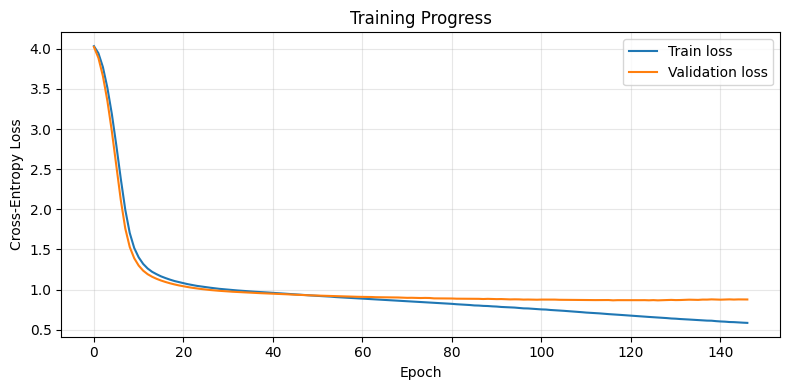

In [18]:
# Plot training curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history["train"], label="Train loss")
ax.plot(history["val"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Progress")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Generating Names

We generate names **autoregressively**: start with `<S>`, predict the next character, append it, and repeat until the model outputs `<E>` or we hit the max length.

The **temperature** parameter controls the randomness:
- **Low temperature** (e.g. 0.5) → more conservative, common patterns
- **High temperature** (e.g. 1.2) → more creative, surprising outputs

In [19]:
def generate_name(model, max_len=25, temperature=1.0):
    """Generate a single Pokémon name using autoregressive sampling."""
    model.eval()
    input_seq = torch.tensor([[char_to_idx[START]]], device=device)
    generated = []

    with torch.no_grad():
        for _ in range(max_len):
            logits = model(input_seq)[0, -1, :]
            probs = F.softmax(logits / temperature, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()

            if next_idx == char_to_idx[END]:
                break

            generated.append(idx_to_char[next_idx])
            input_seq = torch.cat(
                [input_seq, torch.tensor([[next_idx]], device=device)], dim=1
            )

    return "".join(generated)


# Generate names at different temperatures
for temp in [0.5, 0.8, 1.0, 1.2]:
    print(f"\n--- Temperature {temp} ---")
    for _ in range(5):
        print(f"  {generate_name(model, temperature=temp)}")


--- Temperature 0.5 ---
  grotom-ala
  skarmota
  eesparia
  sinily
  goritom-max

--- Temperature 0.8 ---
  silyen-gmax
  brastoun
  inciney
  hohdongo
  orpido

--- Temperature 1.0 ---
  lipraboon
  lhegiopo
  brembust
  tenye-mapox-max
  velgiseir

--- Temperature 1.2 ---
  sq<P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P><P>
  ezaldode
  niykely
  elingaced-5emega
  paxerirago
